# LPDV implementation 

Voilà mon fichier de configuration : 
```toml
[simulation]
output_base_path = "data"

generative_models = ["UNI", "DDD_BETA","DDD_BETA_POLAR", "EUCLID_1D", "EUCLID_2D"]

rule_codes = ["L1DV", "MJ", "L2DV", "RV", "L4DV", "BORD", "STAR", "NANS", "PLU2", "PLU1"]

candidates = [3,5,7,8]

voters = [10,100]

iterations = 500

seed = 161
```

et l'implémentation : 

```py
    result = minimize_scalar(
        lambda y: float(np.sum(np.abs(scores - y) ** p)),
        bounds=(lo, hi),
        method="bounded",
    )
```

In [5]:
from vote_simulation.simulation.simulation import simulation_series_from_config

results = simulation_series_from_config("lpvd.toml", reload=True, compute_metrics=True)

Running simulation series: 100%|███████████████| 40/40 [02:26<00:00,  3.67s/it]

Completed 40 simulation series.


## Résultats 
La première vérification qu'on va faire c'est selon ma biblio lpvd avec p=1 c'est Majority judgment, p=2 équivaut à Range voting. 

     gen_model  n_voters  n_candidates  step_count  n_iterations  mean_distance most_distant_rule_a most_distant_rule_b  most_distant_distance
      DDD_BETA        10             3         500           500      22.117676                PLU2       RANDOM_WINNER              69.599998
      DDD_BETA        10             5         500           500      27.322728                BORD       RANDOM_WINNER              82.900002
      DDD_BETA        10             7         500           500      30.882324     RANDOM_DICTATOR       RANDOM_WINNER              87.900002
      DDD_BETA        10             8         500           500      31.143991     RANDOM_DICTATOR       RANDOM_WINNER              89.300003
      DDD_BETA       100             3         500           500      18.307576     RANDOM_DICTATOR       RANDOM_WINNER              66.699997
      DDD_BETA       100             5         500           500      23.748483                BORD       RANDOM_WINNER              80.500000

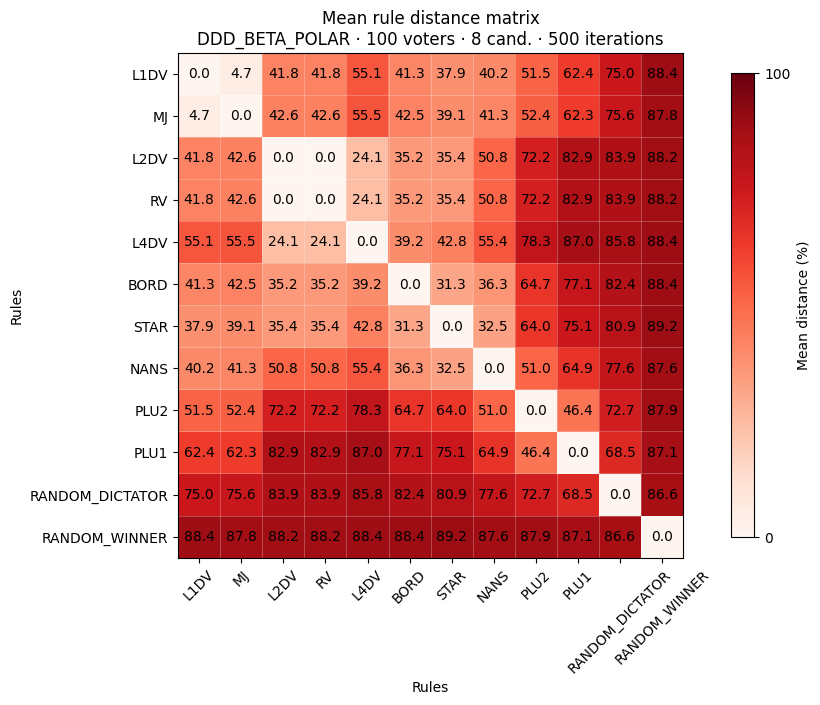

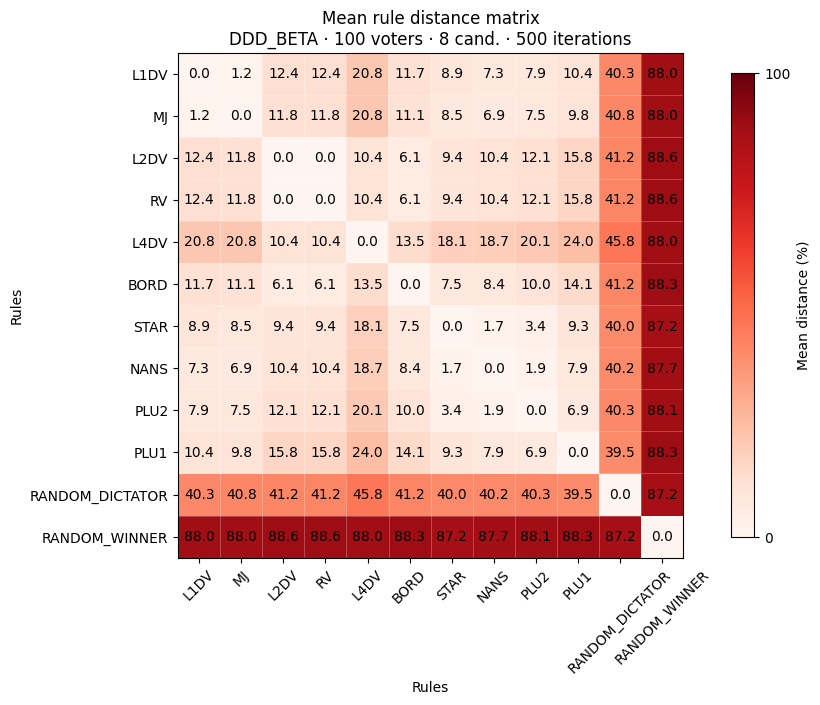

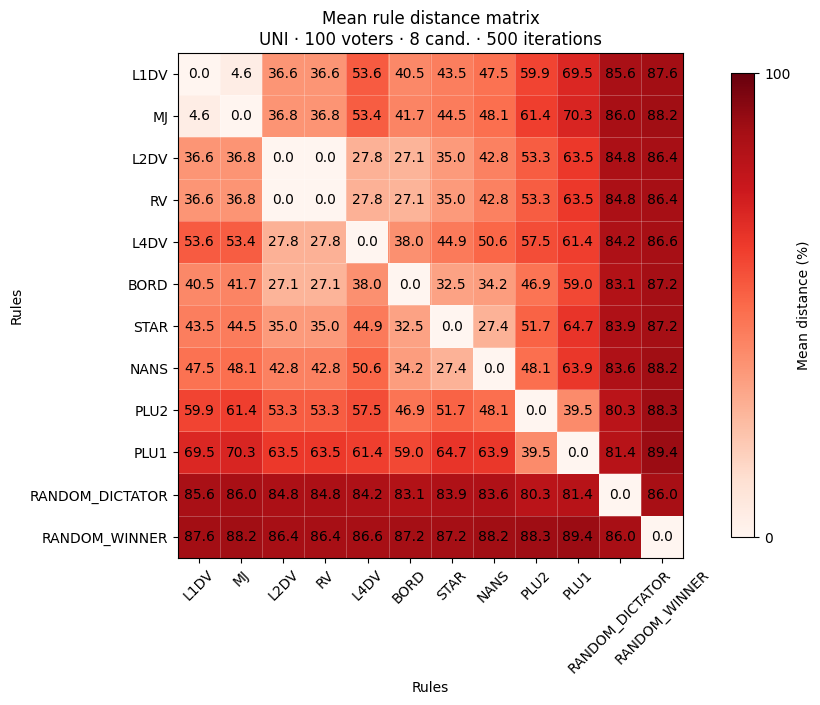

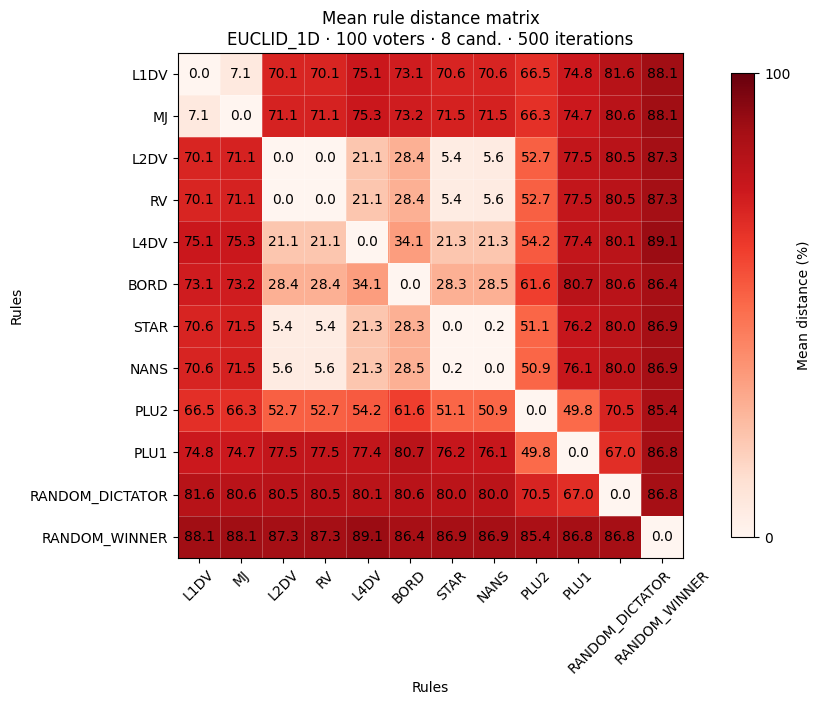

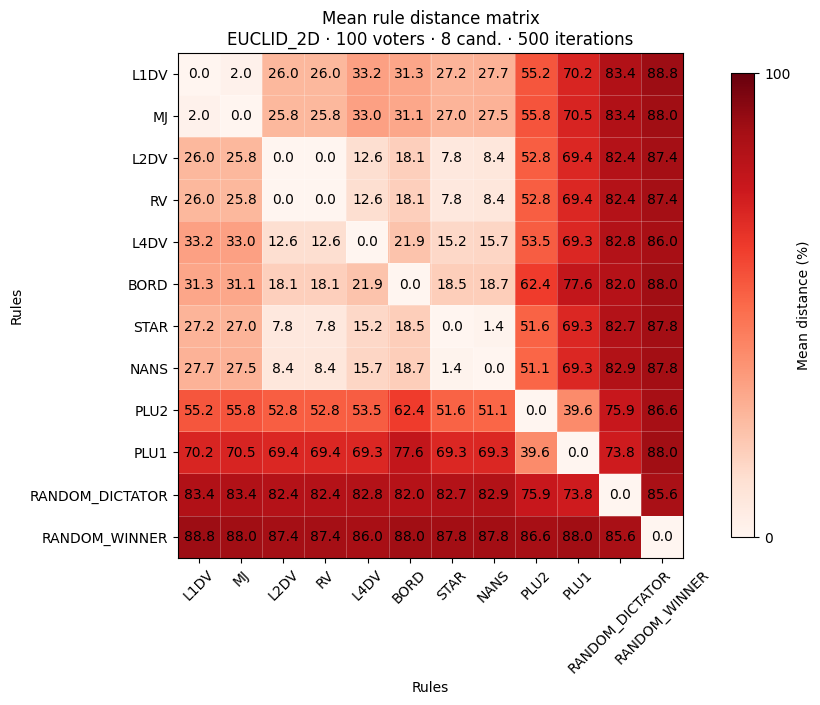

In [6]:
gen_mod = ["DDD_BETA_POLAR", "DDD_BETA", "UNI", "EUCLID_1D", "EUCLID_2D"]
print(results.summary_frame().to_string(index=False))
for g in gen_mod:
    serie = results.get_series(n_candidates=8, gen_model=g, n_voters=100)
    serie.plot_mean_distance_matrix()

J'ai passé un petit moment à me demander pourquoi il restait de la dissimilarité entre p=1 et majority judgment. La raison pour laquelle ça fait ça c'est que majority "discretione" les données donc les valeurs changent un peu mais c'est une différence de médiane continue / discrete.

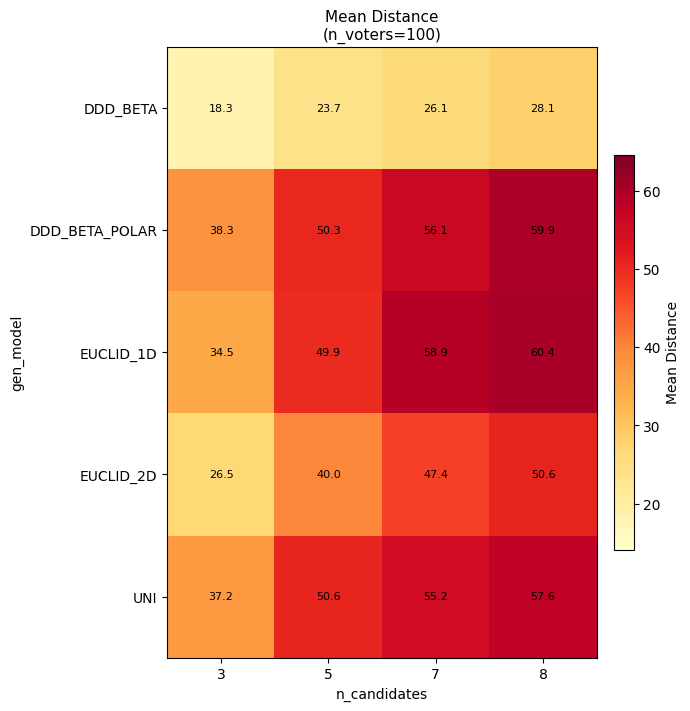

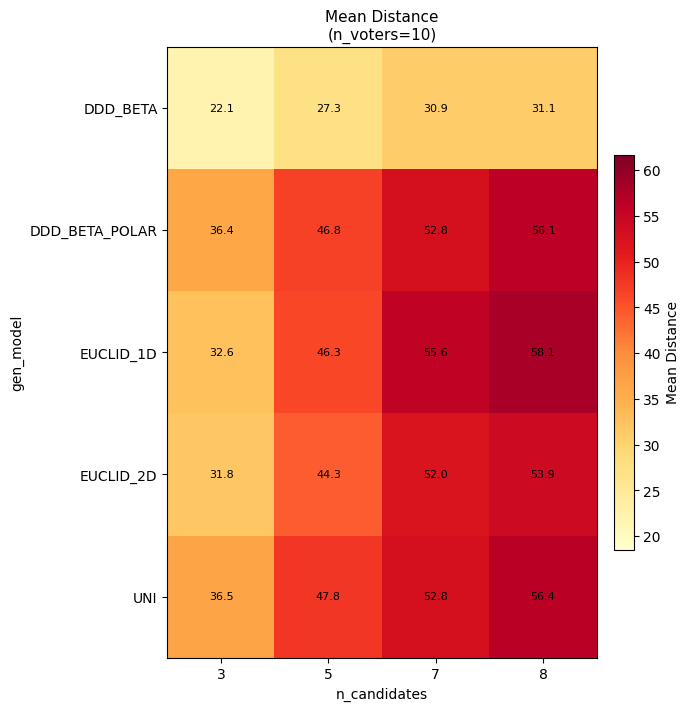

<Axes: title={'center': 'Mean Distance\n(n_voters=10)'}, xlabel='n_candidates', ylabel='gen_model'>

In [7]:
results.filter(n_voters=100).plot_metric_heatmap(row_param="gen_model", col_param="n_candidates")
results.filter(n_voters=10).plot_metric_heatmap(row_param="gen_model", col_param="n_candidates")

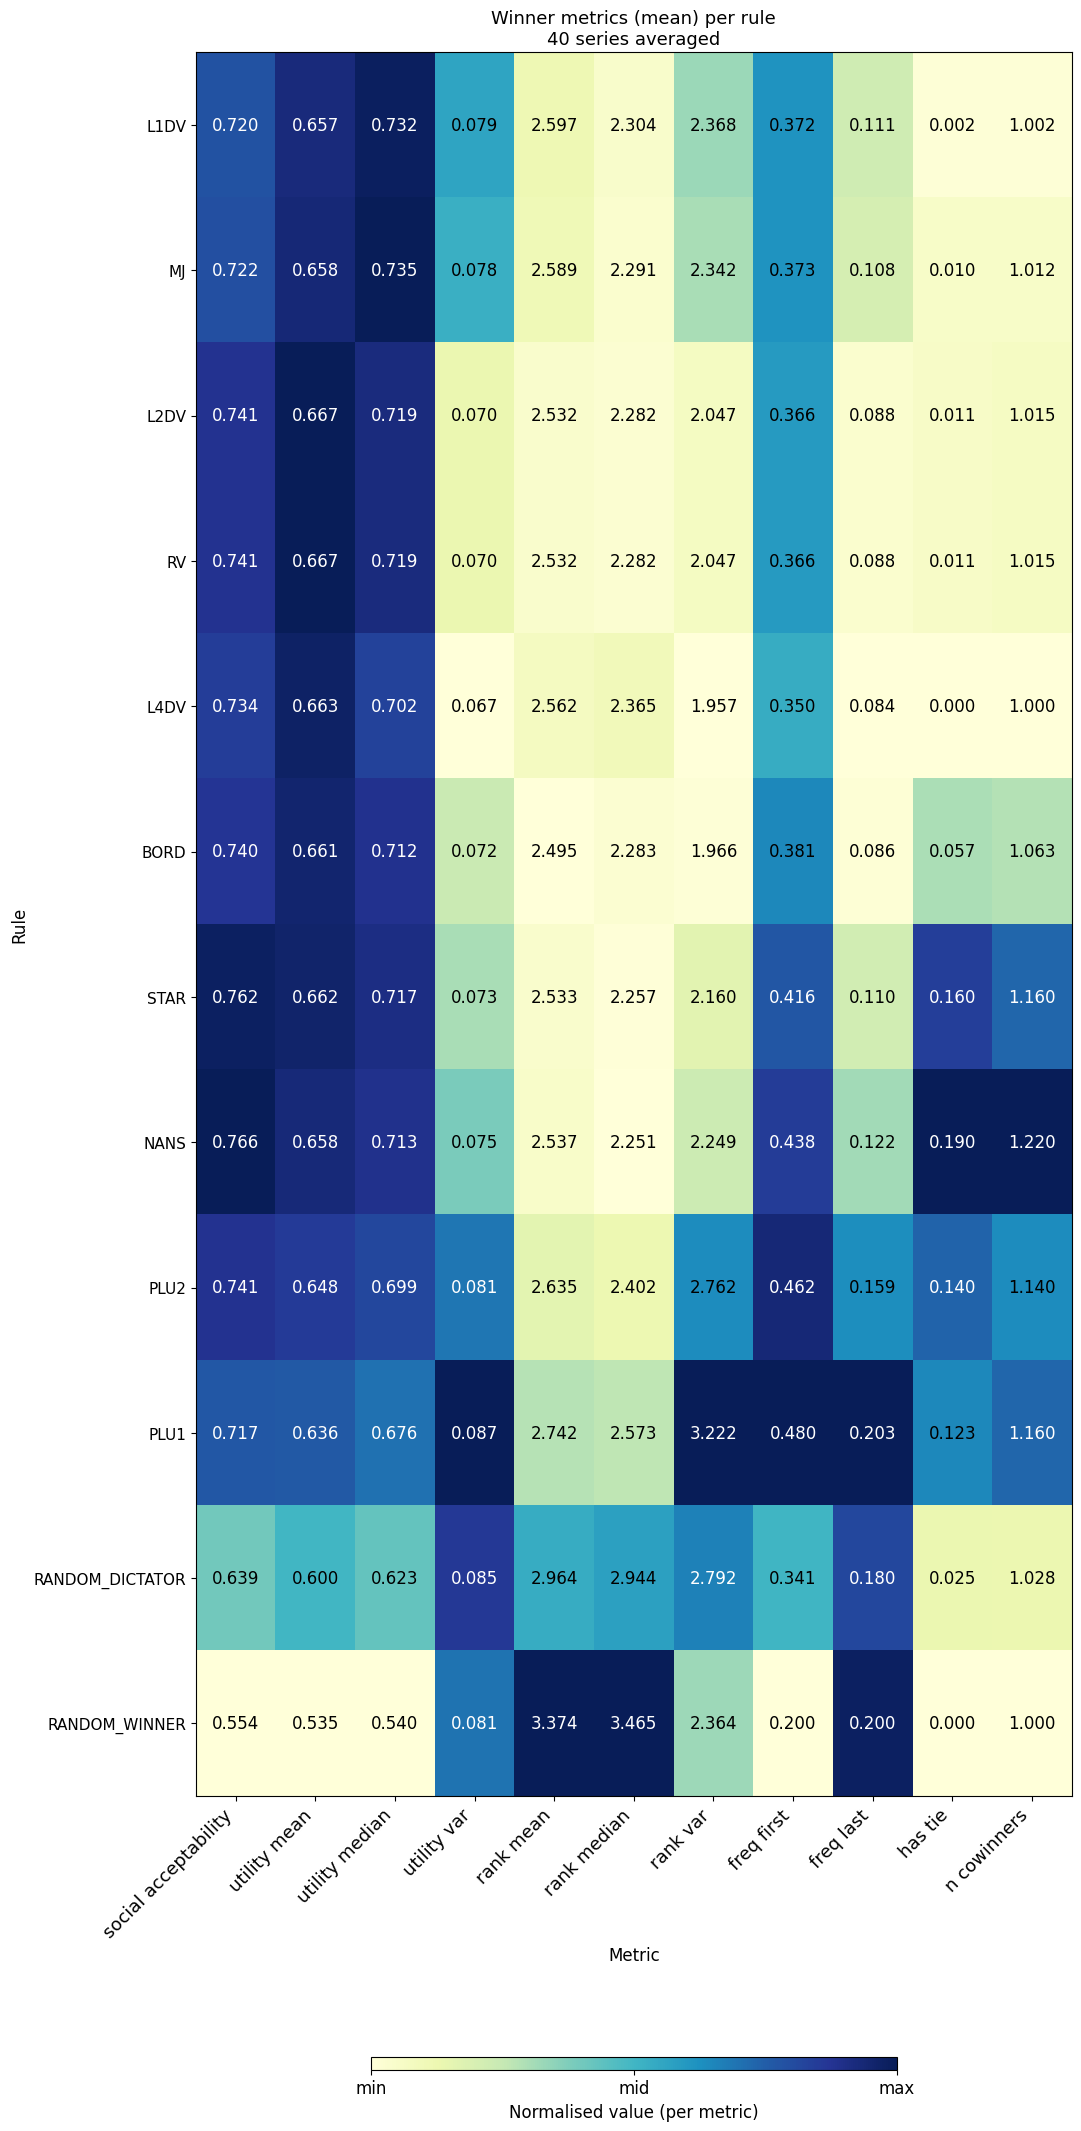

<Axes: title={'center': 'Winner metrics (mean) per rule\n40 series averaged'}, xlabel='Metric', ylabel='Rule'>

In [8]:
results.plot_metrics_rules_matrix()